# Panorama da Despesa com Pessoal dos Estados Brasileiros
## Relatório de Gestão Fiscal — 2015 a 2025

Este notebook analisa quanto da Receita Corrente Líquida (RCL) está comprometido com a Despesa Total com Pessoal (DTP) dos Poderes Executivos estaduais.

**Questão central:** quais estados preservam maior espaço fiscal diante dos limites da Lei de Responsabilidade Fiscal e quais apresentam pressão, recorrência ou deterioração?

> **Escopo:** 27 UFs, exercícios de 2015 a 2025 e último quadrimestre disponível. A análise considera somente o Poder Executivo (`co_poder=E`), pois os limites legais são definidos por poder/órgão.

**Fonte:** API oficial do SICONFI/STN, RGF — Anexo 01. Percentuais e limites declarados no demonstrativo têm prioridade sobre valores recalculados.

### Como ler esta análise

1. Cobertura e qualidade dos dados;
2. situação fiscal no último exercício;
3. ranking anual e score histórico;
4. melhora, deterioração, recorrência e volatilidade;
5. gráficos e síntese para decisão.

DTP/RCL e margens são expressos em **pontos percentuais**. Menor DTP/RCL e maiores margens indicam, em geral, situação mais confortável.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Markdown, HTML, Image

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from rgf.analysis import build_indicators, annual_ranking
from rgf.charts import generate_charts
from rgf.export import executive_summary, export_excel

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
display(HTML('<style>.jp-Notebook{max-width:1250px;margin:auto}.dataframe{font-size:12px}h1,h2,h3{color:#19324D}blockquote{border-left:4px solid #167D5A;padding-left:12px}</style>'))
base = pd.read_csv(ROOT / 'dados/rgf_estados_2015_2025_tratado.csv')
indicadores = build_indicators(base)
ranking = annual_ranking(base)
ultimo_ano = int(base.dropna(subset=['DTP_RCL']).ano.max())

## 1. Cobertura e consistência

A grade esperada possui 297 observações: 27 UFs multiplicadas por 11 exercícios. Dados ausentes permanecem nulos; não são substituídos por zero.

O leiaute do RGF ganhou detalhamento a partir de 2018. Para manter a comparabilidade, o tratamento combina código e descrição normalizada da conta. A origem de cada indicador pode ser auditada em `dados/auditoria_mapeamento.csv`.

In [2]:
cobertura = pd.DataFrame({
    'Indicador': ['Observações esperadas', 'DTP/RCL disponível', 'UFs no último ano', 'Exercícios'],
    'Resultado': [297, int(base.DTP_RCL.notna().sum()), int(base.query('ano == @ultimo_ano').UF.nunique()), int(base.ano.nunique())]
})
display(cobertura.style.hide(axis='index').set_caption('Resumo da cobertura'))
ausencias = pd.read_csv(ROOT / 'dados/ausencias_por_ano.csv')
display(ausencias.style.hide(axis='index').set_caption('Ausências por exercício'))

Indicador,Resultado
Observações esperadas,297
DTP/RCL disponível,297
UFs no último ano,27
Exercícios,11


ano,observacoes,DTP_RCL_ausente,RCL_ausente,RCL_ajustada_ausente,limite_alerta_ausente,limite_prudencial_ausente,limite_maximo_ausente
2015,27,0,0,27,1,1,1
2016,27,0,0,27,0,0,0
2017,27,0,0,0,1,1,1
2018,27,0,0,0,0,0,0
2019,27,0,0,0,0,0,0
2020,27,0,0,0,0,0,0
2021,27,0,0,0,0,0,0
2022,27,0,0,0,0,0,0
2023,27,0,0,0,0,0,0
2024,27,0,0,0,0,0,0


## 2. Situação fiscal no último exercício

A classificação compara o DTP/RCL aos limites declarados no próprio RGF. **Confortável** indica distância relevante do alerta; **atenção** sinaliza aproximação; **alerta** representa superação do limite de alerta; as duas últimas categorias indicam ultrapassagem dos limites prudencial ou máximo.

> A classificação é gerencial. O enquadramento legal definitivo depende do demonstrativo homologado e da avaliação dos órgãos competentes.

In [3]:
atual = base.query('ano == @ultimo_ano').copy()
ordem = ['confortável','atenção','alerta','acima do limite prudencial','acima do limite máximo']
situacao = atual.situacao_fiscal.value_counts().reindex(ordem, fill_value=0).rename_axis('Situação').reset_index(name='UFs')
display(Markdown(f'**Exercício de referência: {ultimo_ano}.**'))
display(situacao.style.hide(axis='index').set_caption('Distribuição da situação fiscal'))
cols = ['UF','nome_estado','DTP_RCL','Limite_Alerta','Limite_Prudencial','Limite_Maximo','Margem_Limite_Prudencial','situacao_fiscal']
pressao = atual.query("situacao_fiscal != 'confortável'")[cols].sort_values('DTP_RCL', ascending=False)
display(pressao.style.format({c:'{:.2f}' for c in cols[2:7]}, na_rep='—').hide(axis='index').set_caption('Estados que exigem atenção'))
regional = atual.groupby('regiao', as_index=False).agg(DTP_RCL_medio=('DTP_RCL','mean'), margem_prudencial_media=('Margem_Limite_Prudencial','mean')).sort_values('DTP_RCL_medio')
display(regional.style.format({'DTP_RCL_medio':'{:.2f}','margem_prudencial_media':'{:.2f}'}).hide(axis='index').set_caption('Comparação regional'))

**Exercício de referência: 2025.**

Situação,UFs
confortável,18
atenção,0
alerta,6
acima do limite prudencial,2
acima do limite máximo,1


UF,nome_estado,DTP_RCL,Limite_Alerta,Limite_Prudencial,Limite_Maximo,Margem_Limite_Prudencial,situacao_fiscal
RN,Rio Grande do Norte,56.41,44.10,46.55,49.00,-9.86,acima do limite máximo
MG,Minas Gerais,48.22,44.10,46.55,49.00,-1.67,acima do limite prudencial
AC,Acre,47.99,44.10,46.55,49.00,-1.44,acima do limite prudencial
RJ,Rio de Janeiro,45.74,44.10,46.55,49.00,0.81,alerta
RR,Roraima,44.80,44.10,46.55,49.00,1.75,alerta
PB,Paraíba,44.74,44.10,46.55,49.00,1.81,alerta
TO,Tocantins,44.31,44.10,46.55,49.00,2.24,alerta
MS,Mato Grosso do Sul,44.20,44.10,46.55,49.00,2.35,alerta
RS,Rio Grande do Sul,44.16,44.10,46.55,49.00,2.39,alerta


regiao,DTP_RCL_medio,margem_prudencial_media
Centro-Oeste,40.48,5.98
Nordeste,41.30,5.21
Norte,41.46,5.04
Sul,41.78,4.77
Sudeste,42.66,3.88


## 3. Ranking e score fiscal

O ranking anual ordena as UFs do menor para o maior DTP/RCL. Como uma fotografia isolada não captura trajetória e recorrência, o ranking histórico usa um score de 0 a 100.

$$Score = 100 \times (0{,}30N + 0{,}20P + 0{,}15M + 0{,}15R + 0{,}10T + 0{,}10V)$$

- **N — nível (30%):** menor média histórica do DTP/RCL;
- **P — margem prudencial (20%):** maior distância média do prudencial;
- **M — margem máxima (15%):** maior distância média do máximo;
- **R — recorrência (15%):** menos anos acima do alerta;
- **T — tendência (10%):** trajetória recente mais favorável;
- **V — volatilidade (10%):** maior estabilidade anual.

Cada componente é transformado em percentil entre as 27 UFs. Os grupos representam os terços superior, central e inferior do score.

In [4]:
ra = atual[['ranking_ano','UF','nome_estado','DTP_RCL','Limite_Prudencial','Margem_Limite_Prudencial','situacao_fiscal']].sort_values('ranking_ano')
display(ra.style.format({'ranking_ano':'{:.0f}','DTP_RCL':'{:.2f}','Limite_Prudencial':'{:.2f}','Margem_Limite_Prudencial':'{:.2f}'}, na_rep='—').hide(axis='index').set_caption(f'Ranking anual — {ultimo_ano}'))
rh = indicadores[['ranking_historico','UF','nome_estado','score_fiscal','media_2015_2025','media_margem_prudencial','tendencia_recente','grupo']]
display(rh.style.format({'ranking_historico':'{:.0f}','score_fiscal':'{:.1f}','media_2015_2025':'{:.2f}','media_margem_prudencial':'{:.2f}'}, na_rep='—').hide(axis='index').set_caption('Ranking histórico multidimensional'))

ranking_ano,UF,nome_estado,DTP_RCL,Limite_Prudencial,Margem_Limite_Prudencial,situacao_fiscal
1,MA,Maranhão,30.14,46.55,16.41,confortável
2,ES,Espírito Santo,35.41,46.55,11.14,confortável
3,MT,Mato Grosso,36.28,46.55,10.27,confortável
4,PI,Piauí,37.80,46.55,8.75,confortável
5,PA,Pará,38.07,46.17,8.10,confortável
6,AM,Amazonas,38.09,46.55,8.46,confortável
7,AP,Amapá,38.46,46.55,8.09,confortável
8,RO,Rondônia,38.49,46.55,8.06,confortável
9,SC,Santa Catarina,38.72,46.55,7.83,confortável
10,AL,Alagoas,38.77,46.55,7.78,confortável


ranking_historico,UF,nome_estado,score_fiscal,media_2015_2025,media_margem_prudencial,tendencia_recente,grupo
1,MA,Maranhão,91.1,37.91,8.64,melhora,GRUPO 1 – Melhor situação fiscal
2,ES,Espírito Santo,88.7,38.99,7.56,melhora,GRUPO 1 – Melhor situação fiscal
3,AP,Amapá,88.0,41.53,5.02,melhora,GRUPO 1 – Melhor situação fiscal
4,CE,Ceará,83.5,42.23,4.25,melhora,GRUPO 1 – Melhor situação fiscal
5,RO,Rondônia,83.3,39.90,6.65,estável,GRUPO 1 – Melhor situação fiscal
6,PA,Pará,71.7,42.41,3.76,melhora,GRUPO 1 – Melhor situação fiscal
7,BA,Bahia,71.4,41.97,4.76,deterioração,GRUPO 1 – Melhor situação fiscal
8,PI,Piauí,68.6,42.74,3.81,melhora,GRUPO 1 – Melhor situação fiscal
9,AL,Alagoas,65.4,42.77,3.78,melhora,GRUPO 1 – Melhor situação fiscal
10,DF,Distrito Federal,65.2,42.57,3.98,deterioração,GRUPO 2 – Situação intermediária


## 4. Destaques e sinais de risco

As dimensões abaixo devem ser lidas separadamente. Um estado pode ter bom nível médio, mas estar em deterioração recente; outro pode ter indicador elevado, porém em trajetória de melhora.

**Melhora/piora** é a diferença entre o primeiro e o último exercício; **tendência recente** é a inclinação dos três últimos anos; **volatilidade** é o desvio-padrão da série; e **recorrência** conta os exercícios acima dos limites.

In [5]:
quadros = [
 ('Cinco melhores scores','Maior equilíbrio no conjunto dos critérios.',indicadores.nsmallest(5,'ranking_historico'),['ranking_historico','UF','nome_estado','score_fiscal','grupo']),
 ('Cinco piores scores','Maior pressão relativa no conjunto dos critérios.',indicadores.nlargest(5,'ranking_historico'),['ranking_historico','UF','nome_estado','score_fiscal','grupo']),
 ('Maiores melhoras','Valores negativos indicam redução do DTP/RCL.',indicadores.nsmallest(5,'variacao_primeiro_ultimo_pp'),['UF','nome_estado','variacao_primeiro_ultimo_pp','media_2015_2025']),
 ('Maiores deteriorações','Valores positivos indicam aumento do DTP/RCL.',indicadores.nlargest(5,'variacao_primeiro_ultimo_pp'),['UF','nome_estado','variacao_primeiro_ultimo_pp','media_2015_2025']),
 ('Maior recorrência','Pressão persistente, mesmo quando o último ano melhora.',indicadores.sort_values(['anos_acima_maximo','anos_acima_prudencial','anos_acima_alerta'],ascending=False).head(5),['UF','nome_estado','anos_acima_alerta','anos_acima_prudencial','anos_acima_maximo']),
 ('Maior volatilidade','Oscilações elevadas reduzem a previsibilidade.',indicadores.nlargest(5,'volatilidade_desvio_padrao'),['UF','nome_estado','volatilidade_desvio_padrao','tendencia_recente']),
 ('Deterioração recente','Inclinação positiva indica aumento do DTP/RCL.',indicadores.nlargest(5,'tendencia_recente_pp_ano'),['UF','nome_estado','tendencia_recente_pp_ano','media_ultimos_3_anos']),
 ('Melhora recente','Inclinação negativa indica redução do DTP/RCL.',indicadores.nsmallest(5,'tendencia_recente_pp_ano'),['UF','nome_estado','tendencia_recente_pp_ano','media_ultimos_3_anos'])]
for titulo, texto, tabela, colunas in quadros:
    display(Markdown(f'### {titulo}\n{texto}'))
    formatos = {c:'{:.2f}' for c in colunas if c not in ['UF','nome_estado','grupo','tendencia_recente','ranking_historico','anos_acima_alerta','anos_acima_prudencial','anos_acima_maximo']}
    display(tabela[colunas].style.format(formatos, na_rep='—').hide(axis='index'))

### Cinco melhores scores
Maior equilíbrio no conjunto dos critérios.

ranking_historico,UF,nome_estado,score_fiscal,grupo
1,MA,Maranhão,91.11,GRUPO 1 – Melhor situação fiscal
2,ES,Espírito Santo,88.70,GRUPO 1 – Melhor situação fiscal
3,AP,Amapá,87.96,GRUPO 1 – Melhor situação fiscal
4,CE,Ceará,83.52,GRUPO 1 – Melhor situação fiscal
5,RO,Rondônia,83.33,GRUPO 1 – Melhor situação fiscal


### Cinco piores scores
Maior pressão relativa no conjunto dos critérios.

ranking_historico,UF,nome_estado,score_fiscal,grupo
27,RN,Rio Grande do Norte,8.70,GRUPO 3 – Pior situação fiscal
26,MG,Minas Gerais,13.70,GRUPO 3 – Pior situação fiscal
25,AC,Acre,16.11,GRUPO 3 – Pior situação fiscal
24,TO,Tocantins,18.89,GRUPO 3 – Pior situação fiscal
23,RJ,Rio de Janeiro,24.54,GRUPO 3 – Pior situação fiscal


### Maiores melhoras
Valores negativos indicam redução do DTP/RCL.

...

UF,nome_estado,volatilidade_desvio_padrao,tendencia_recente
RJ,Rio de Janeiro,8.26,melhora
MT,Mato Grosso,7.43,melhora
MG,Minas Gerais,5.80,melhora
TO,Tocantins,5.74,melhora
RN,Rio Grande do Norte,5.63,melhora


### Deterioração recente
Inclinação positiva indica aumento do DTP/RCL.

UF,nome_estado,tendencia_recente_pp_ano,media_ultimos_3_anos
DF,Distrito Federal,3.33,38.61
BA,Bahia,0.19,40.66
RO,Rondônia,0.13,38.04
AC,Acre,-0.21,47.72
MS,Mato Grosso do Sul,-0.22,44.68


### Melhora recente
Inclinação negativa indica redução do DTP/RCL.

UF,nome_estado,tendencia_recente_pp_ano,media_ultimos_3_anos
MA,Maranhão,-3.21,32.58
RR,Roraima,-2.24,47.12
AL,Alagoas,-2.12,39.29
PA,Pará,-2.08,40.29
SC,Santa Catarina,-1.93,40.32


## 5. Gráficos executivos

As visualizações são complementares: o ranking mostra a posição atual; as séries e o heatmap revelam persistência; as margens medem o espaço até os limites; e o score resume desempenho e risco históricos.

> Nos gráficos de margem, valores negativos indicam ultrapassagem. No ranking do score, valores maiores representam melhor situação relativa.

### Ranking no último ano
Barras menores indicam menor comprometimento; as cores refletem a situação fiscal.

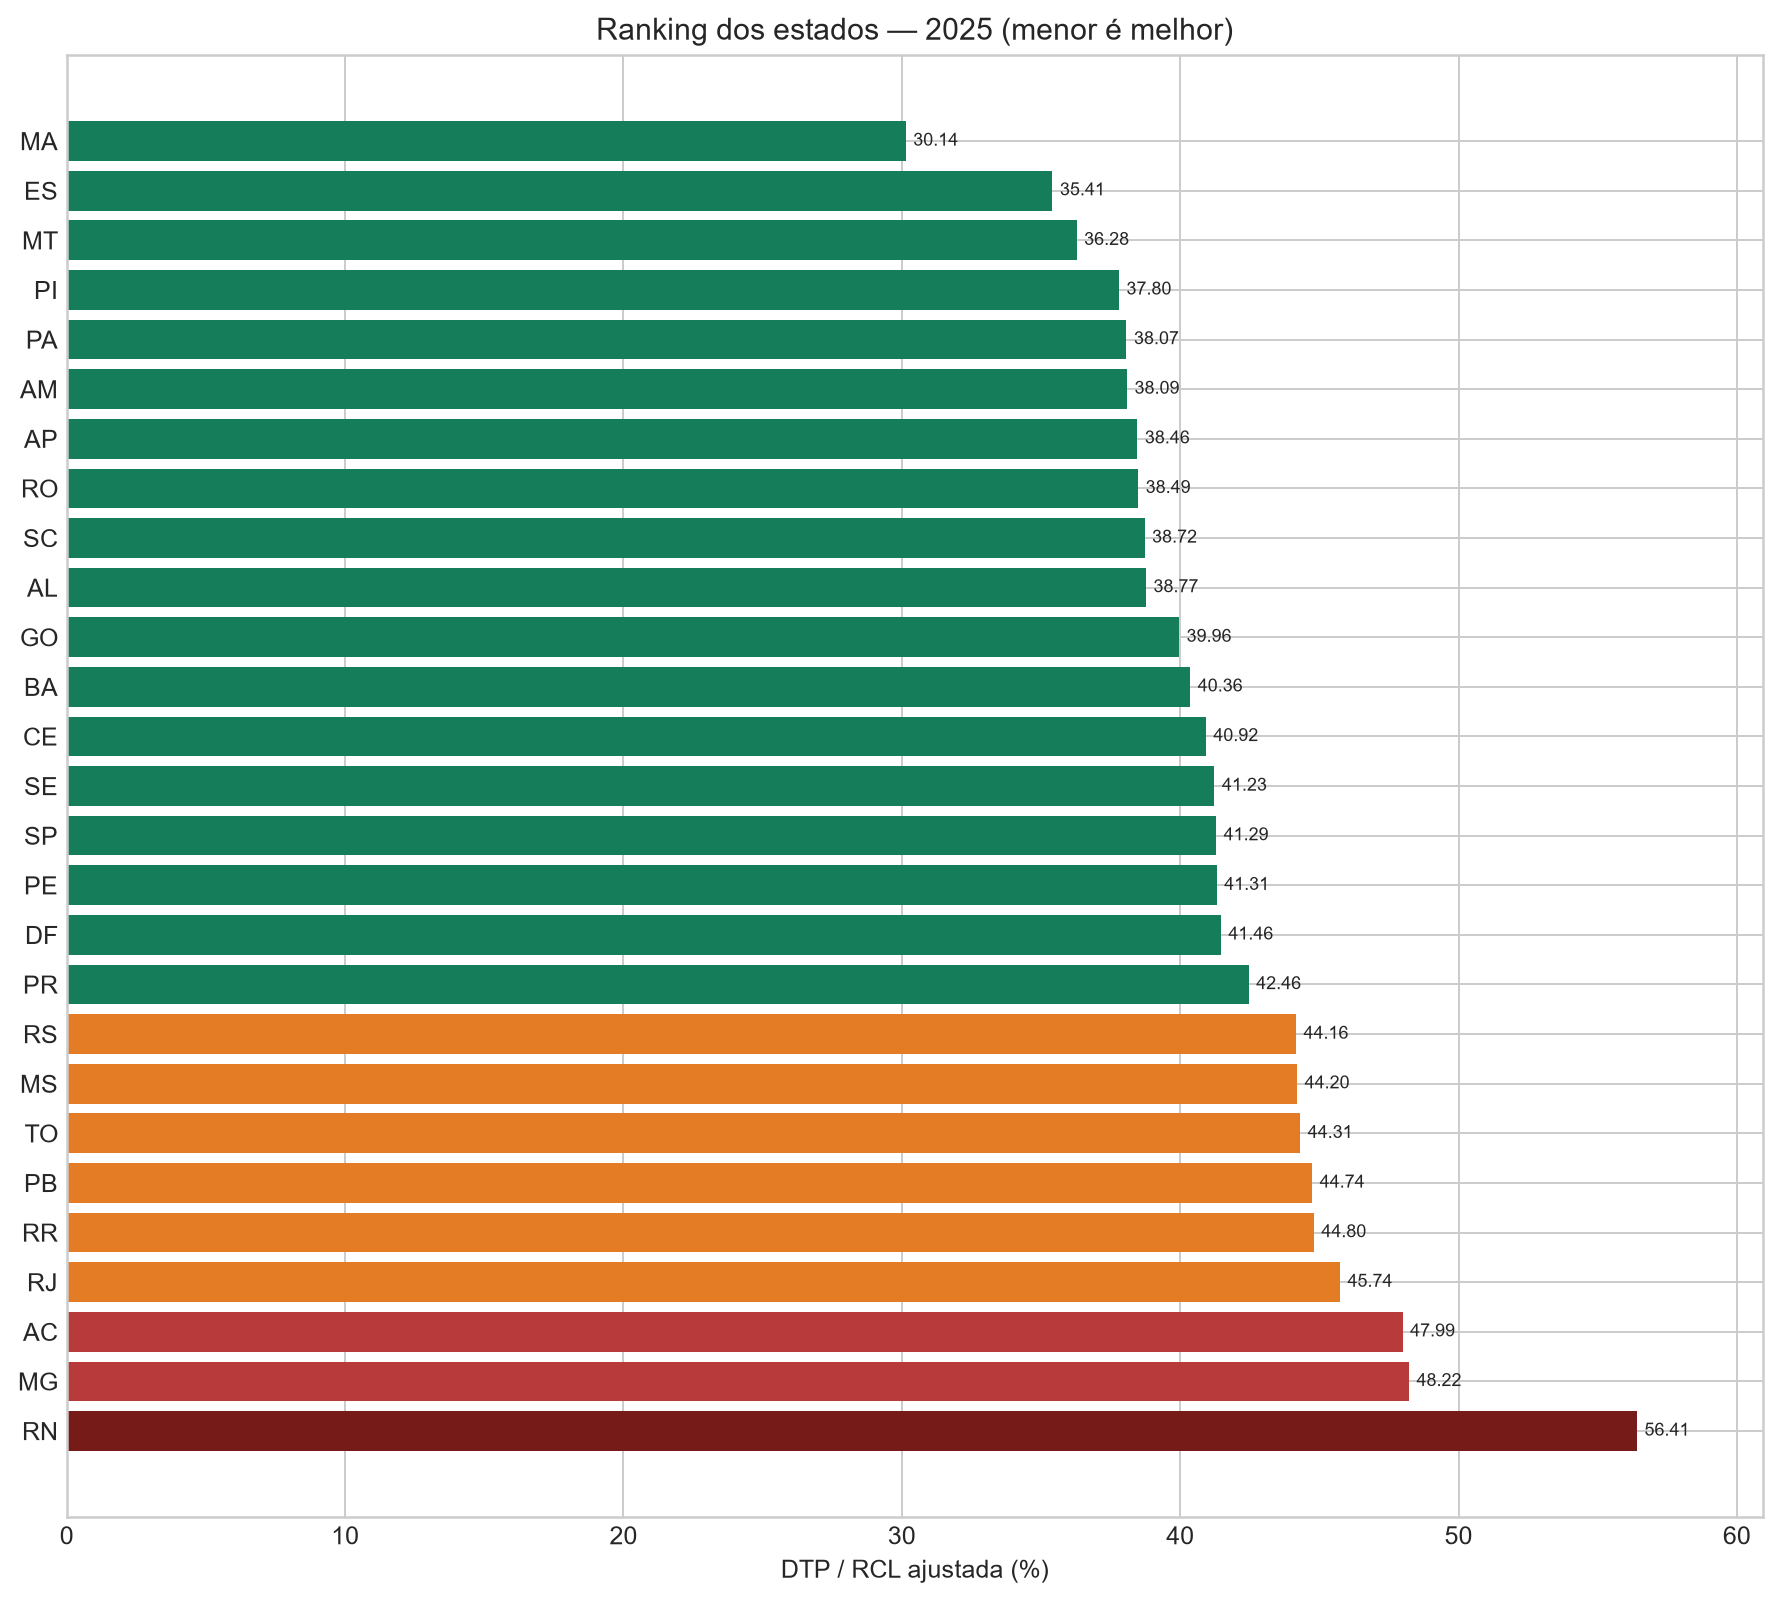

### Evolução de todos os estados
Revela mudanças de patamar, convergência e divergência ao longo do tempo.

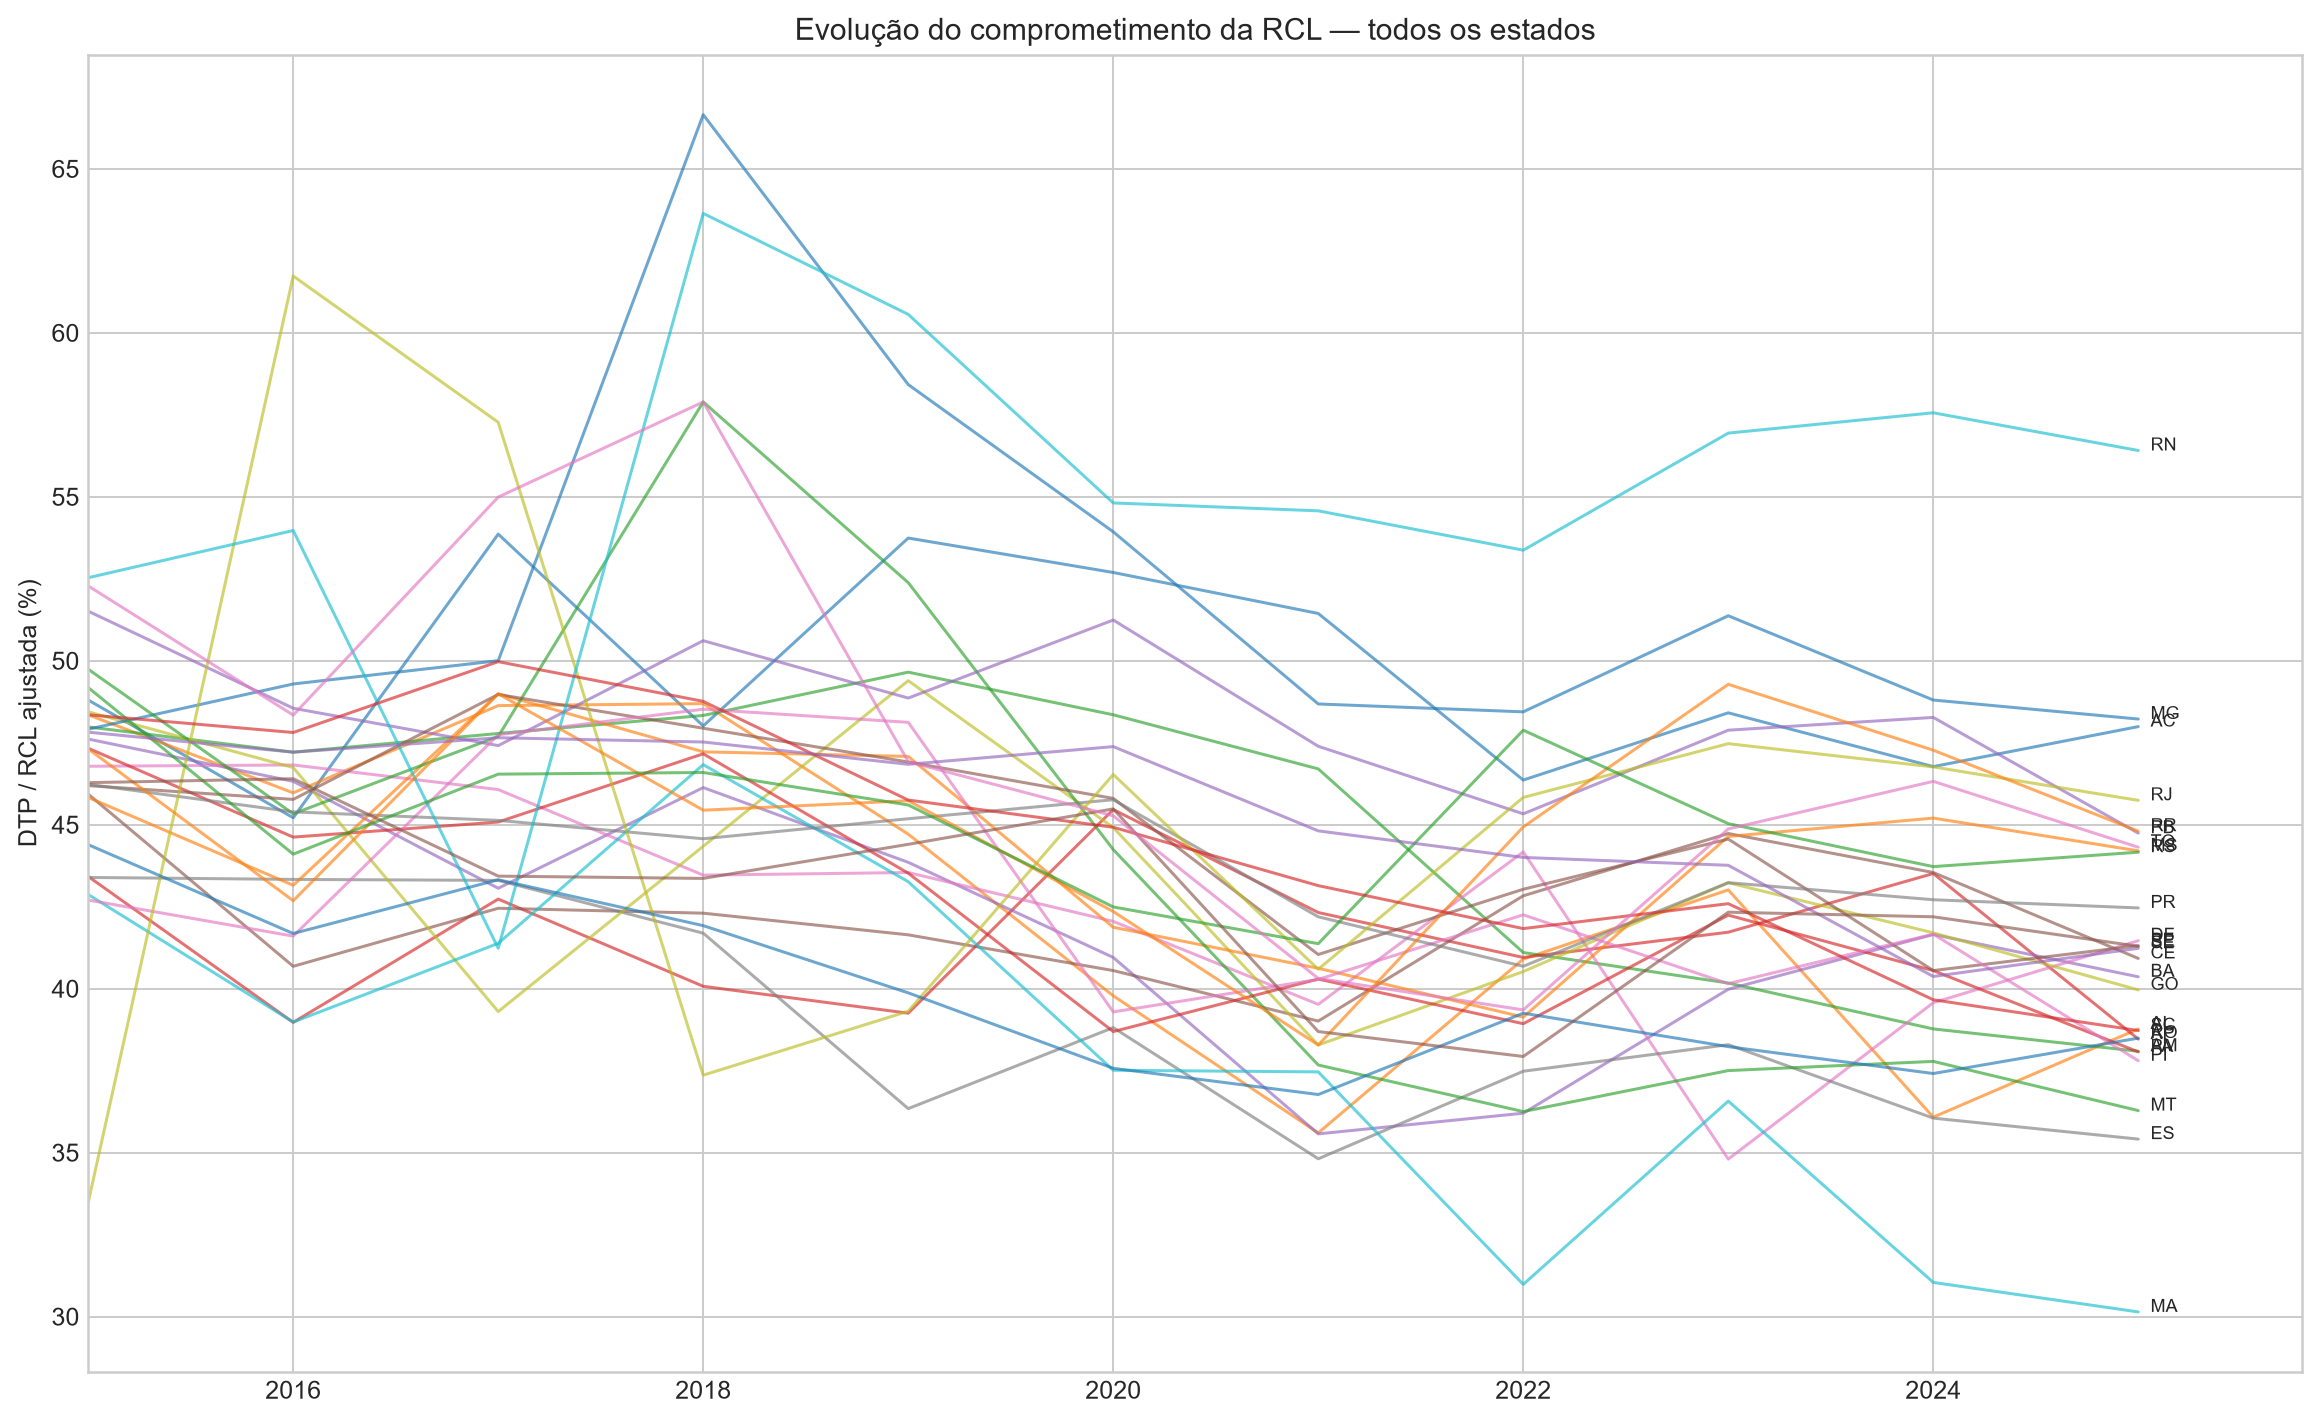

### Trajetória dos extremos
Contrasta os cinco melhores e os cinco piores scores.

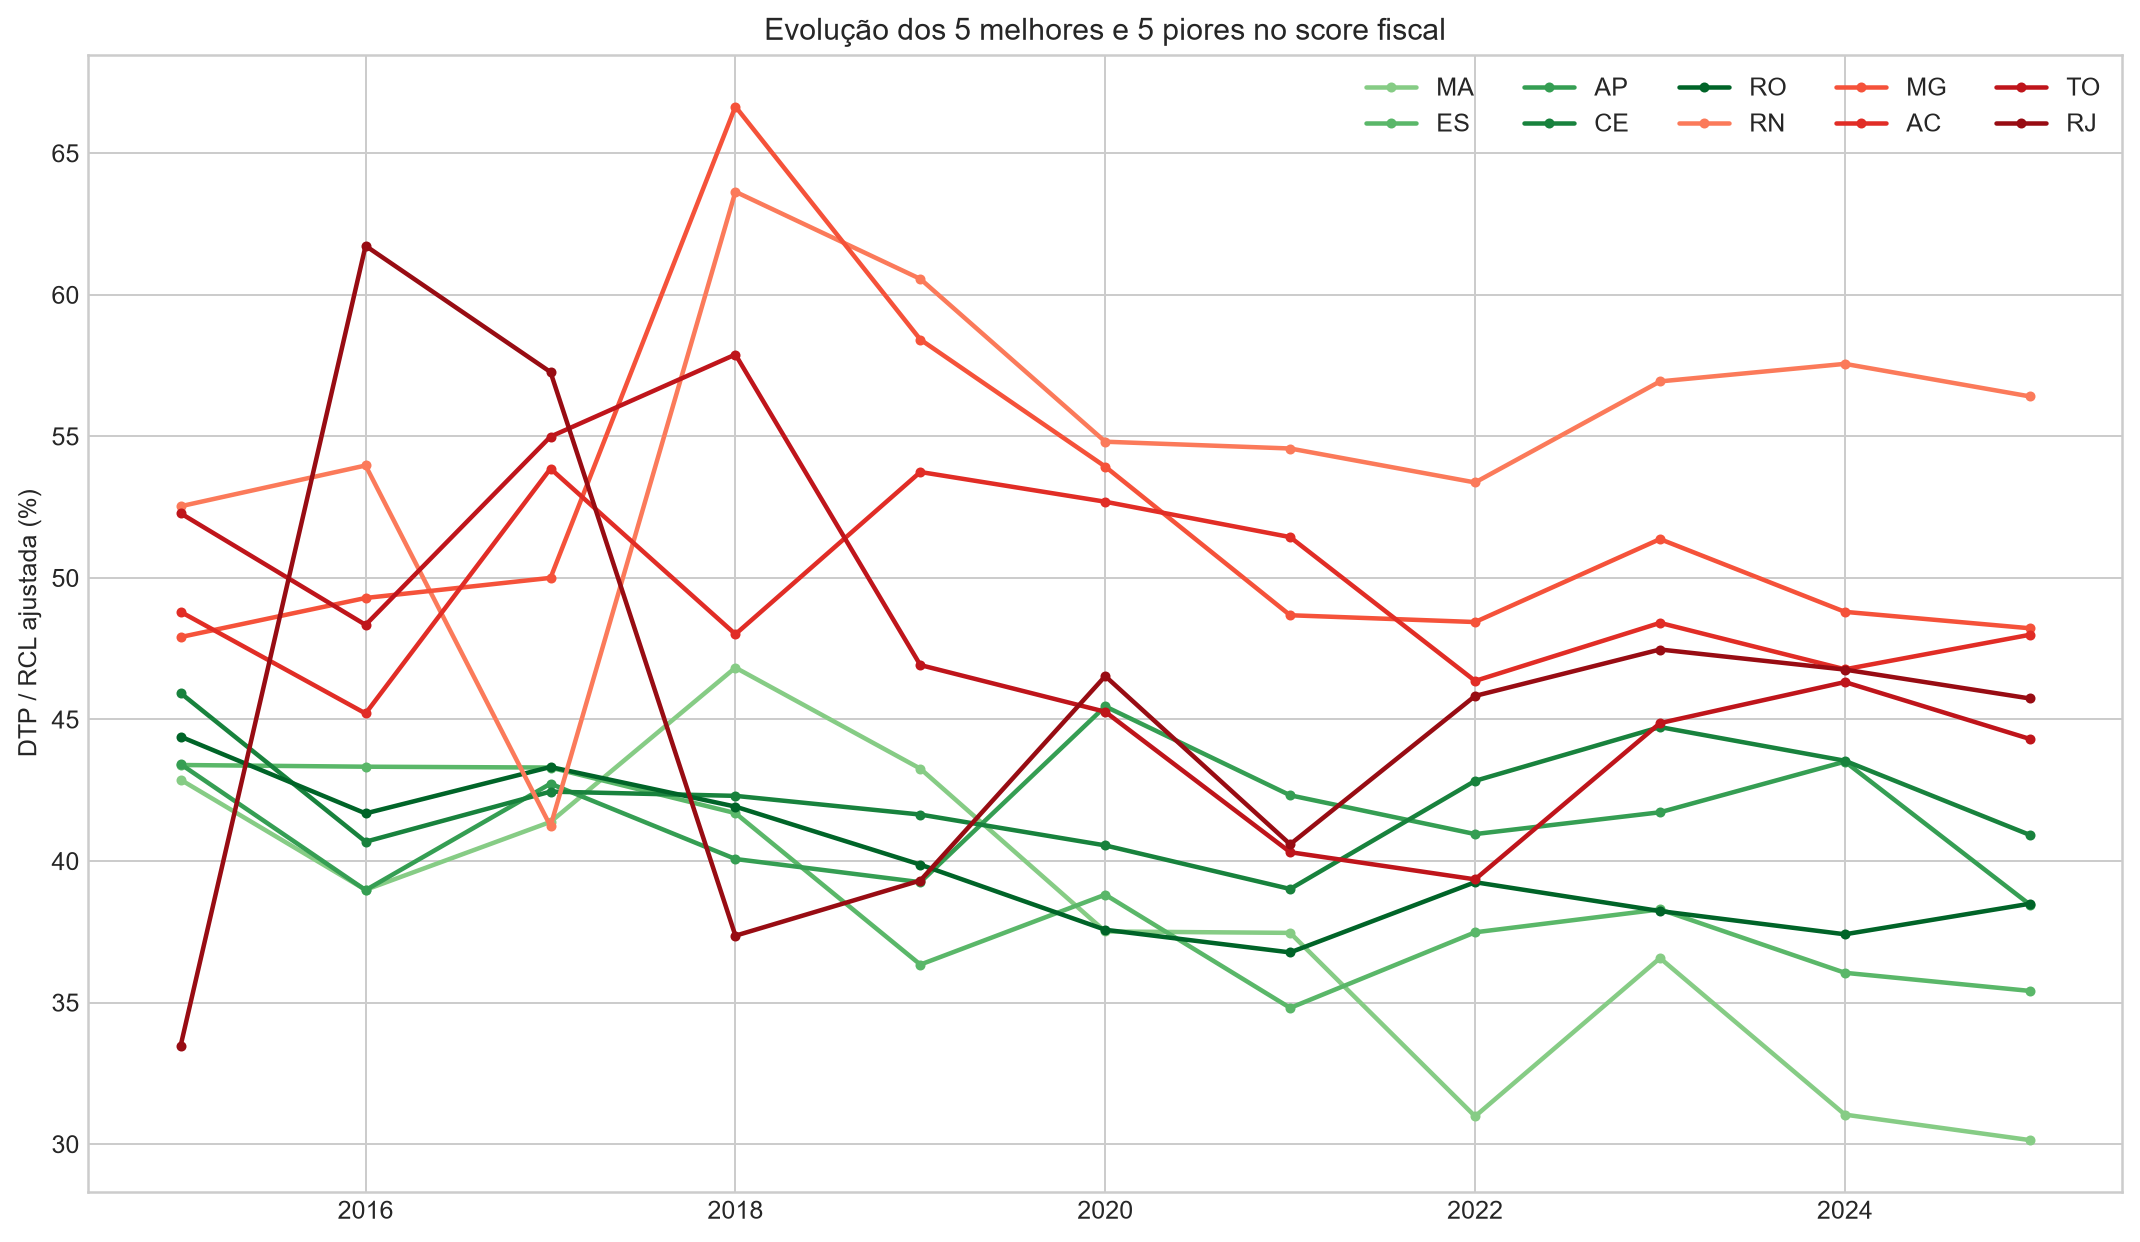

### Mapa de calor Estado × Ano
Tons quentes indicam maior comprometimento e ajudam a reconhecer persistência.

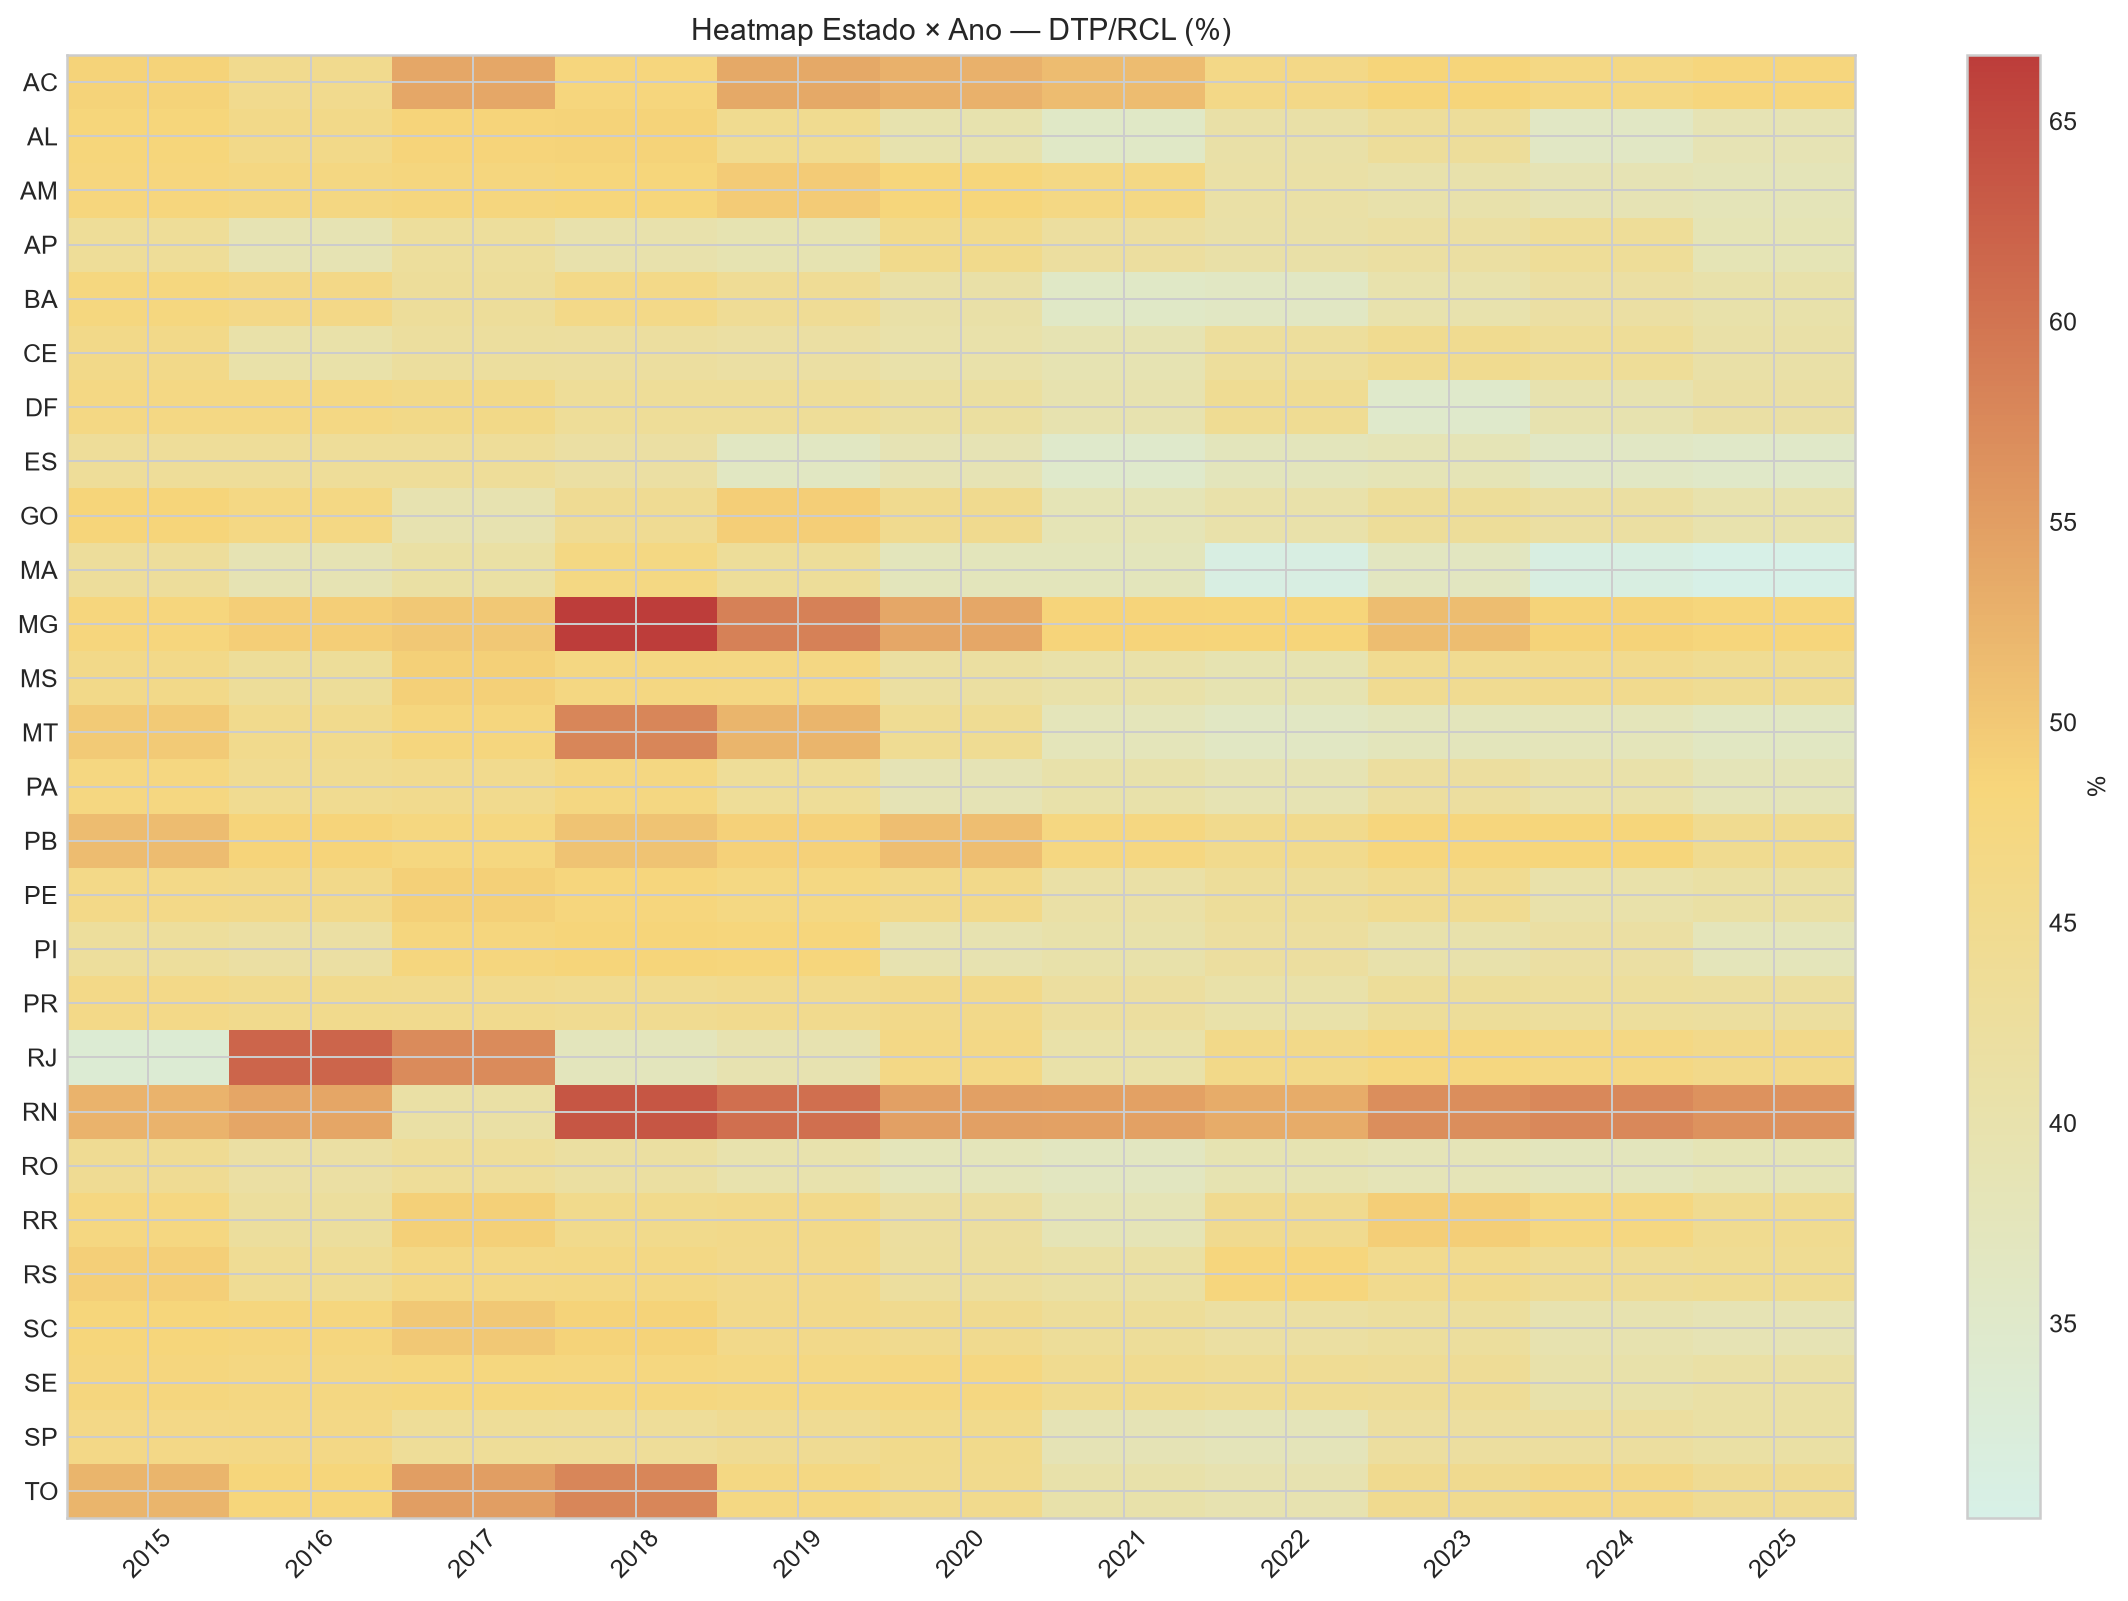

### Margem prudencial
Mostra o espaço em pontos percentuais; valores negativos exigem atenção.

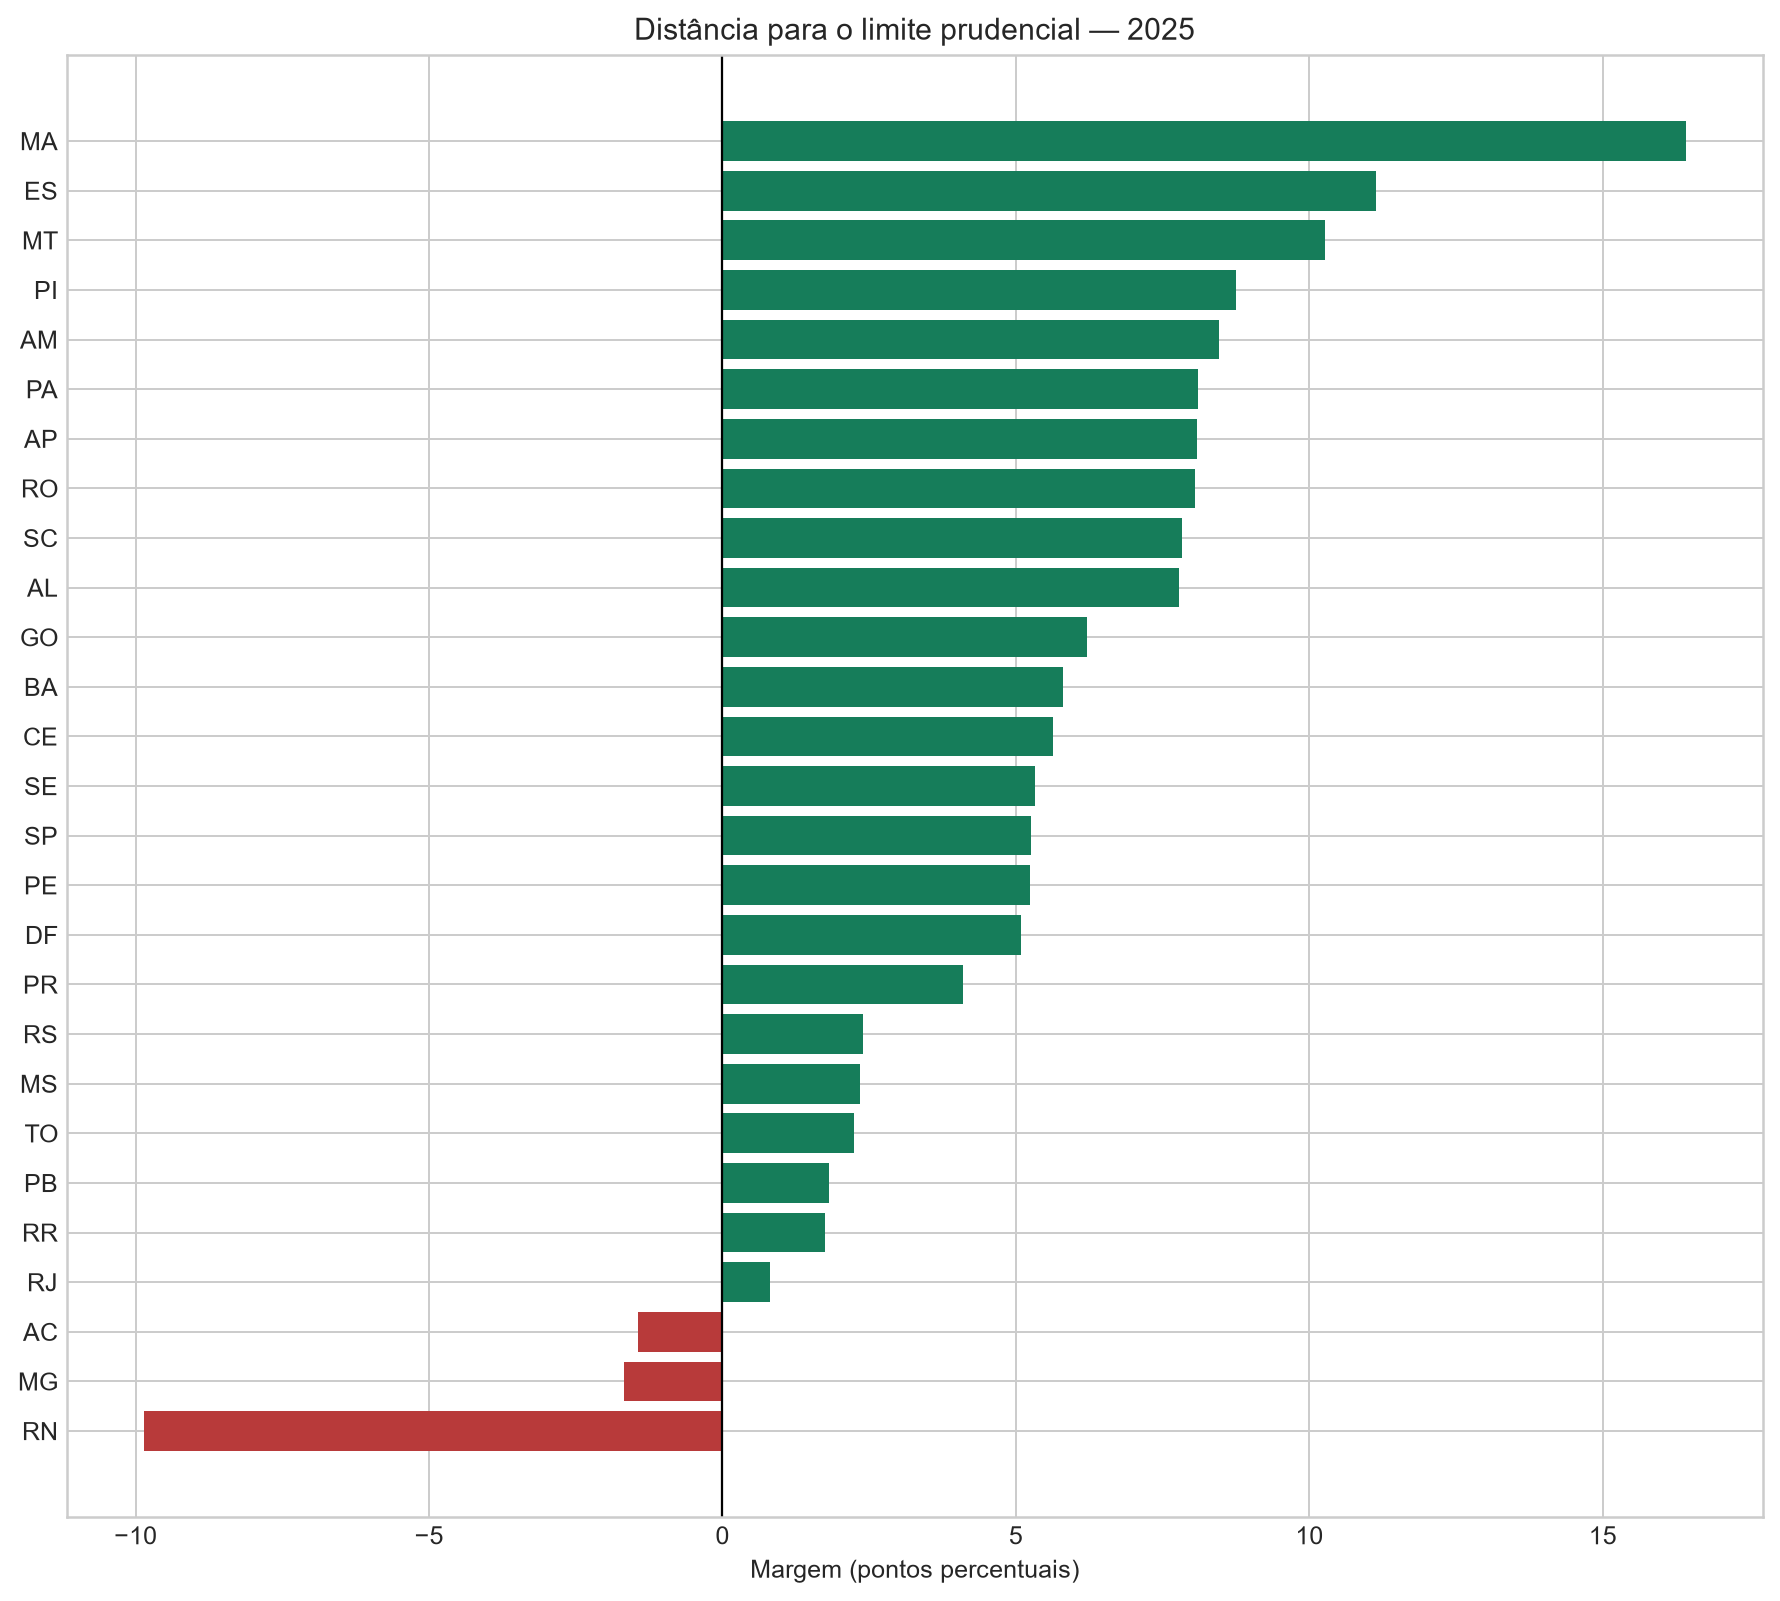

### Margem máxima
Evidencia a distância do patamar legal mais crítico.

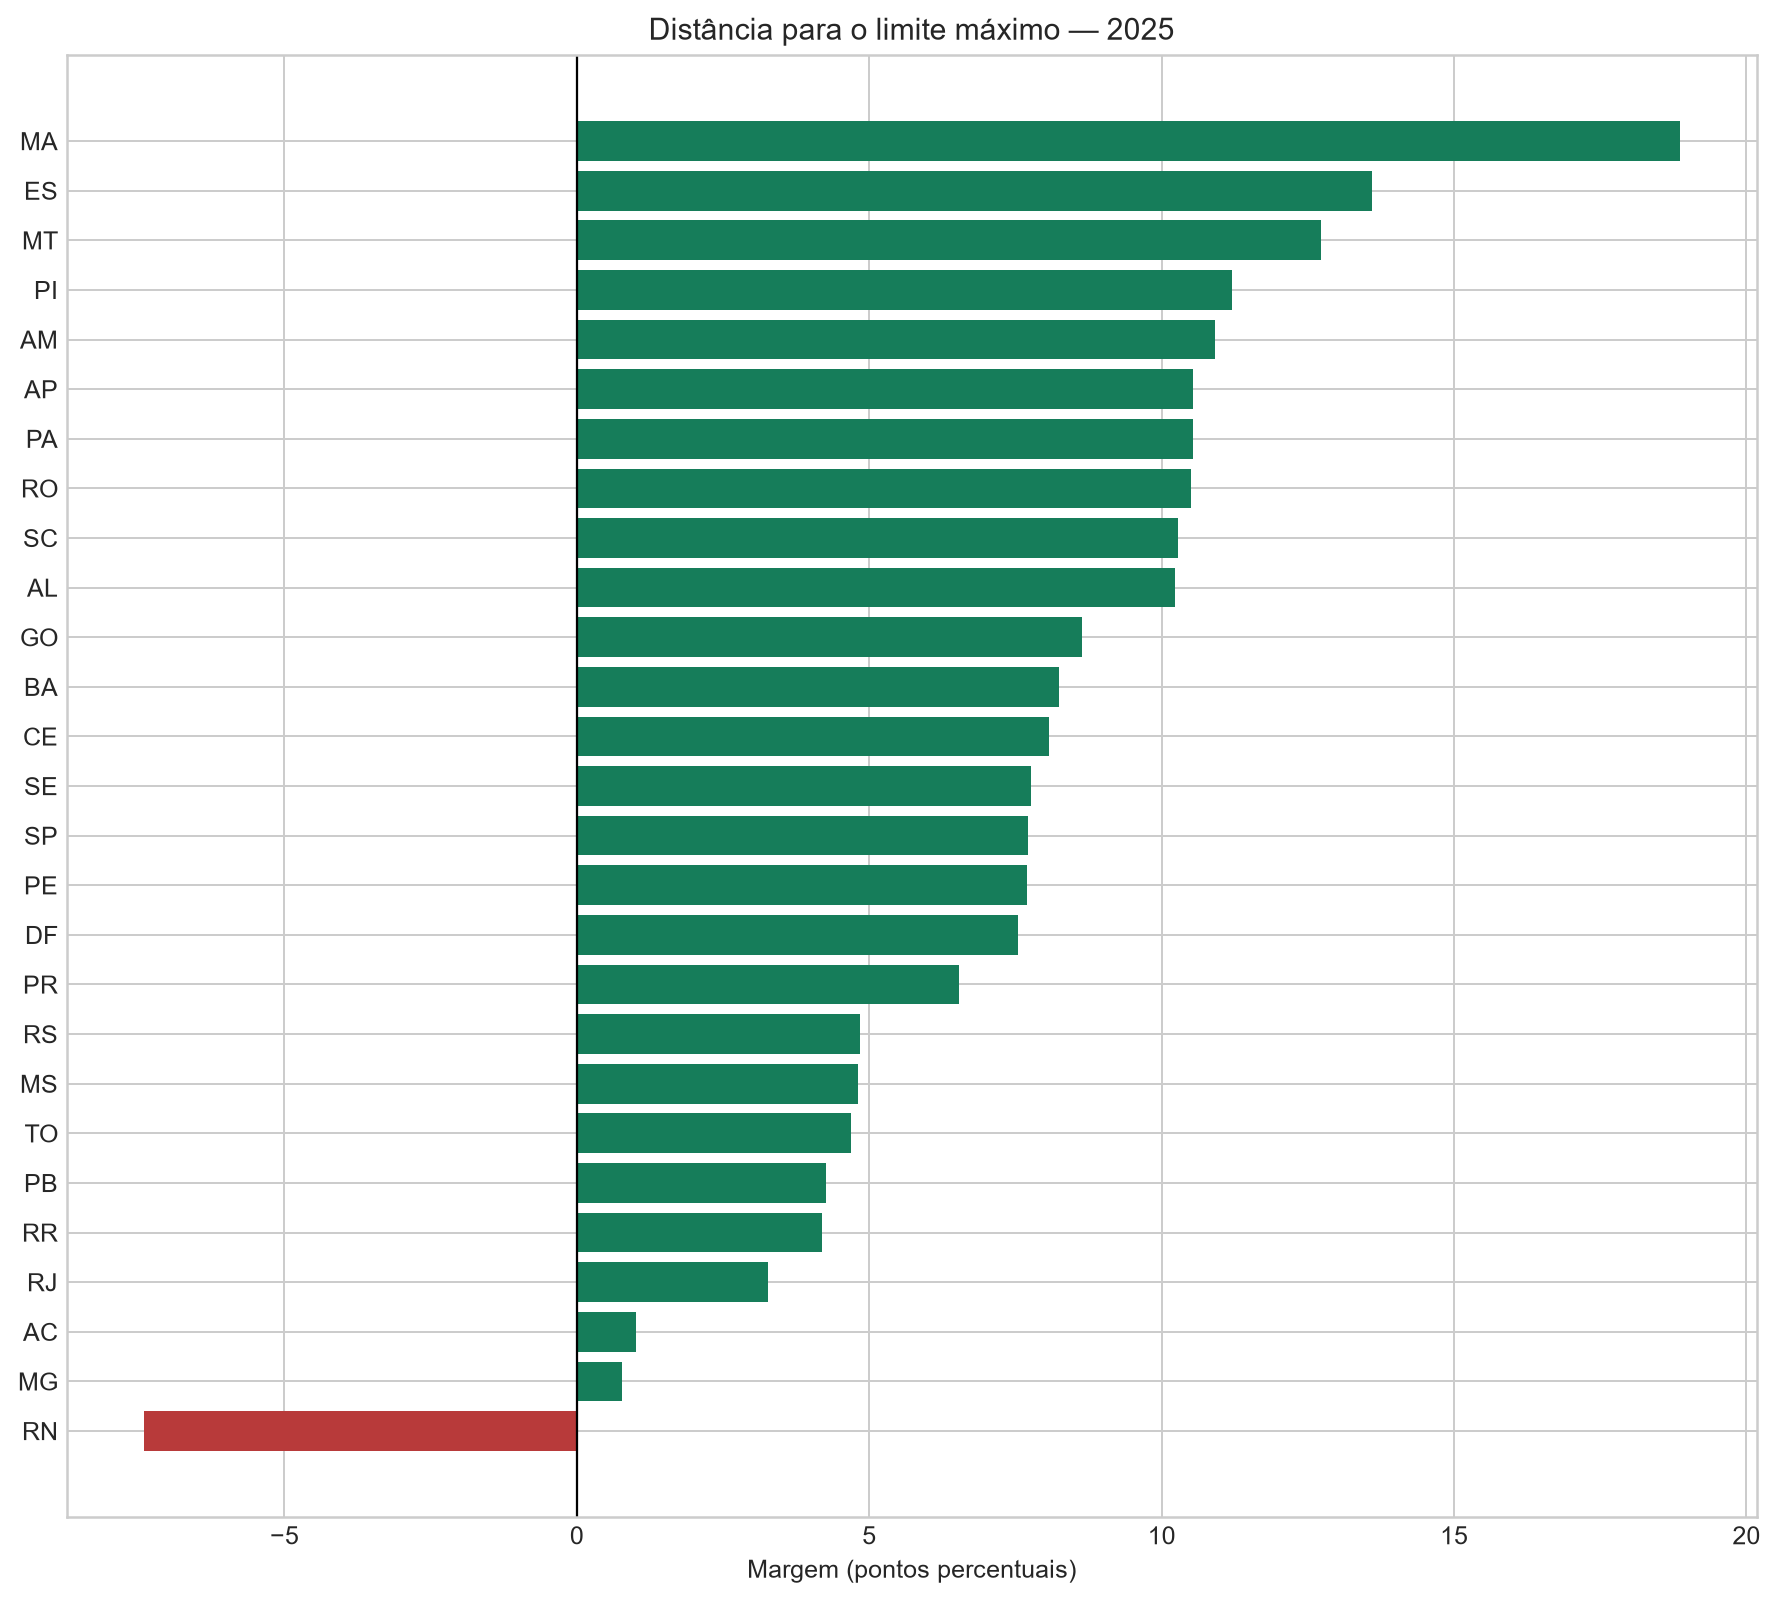

### Ranking do score
Agrega nível, margens, recorrência, tendência e volatilidade.

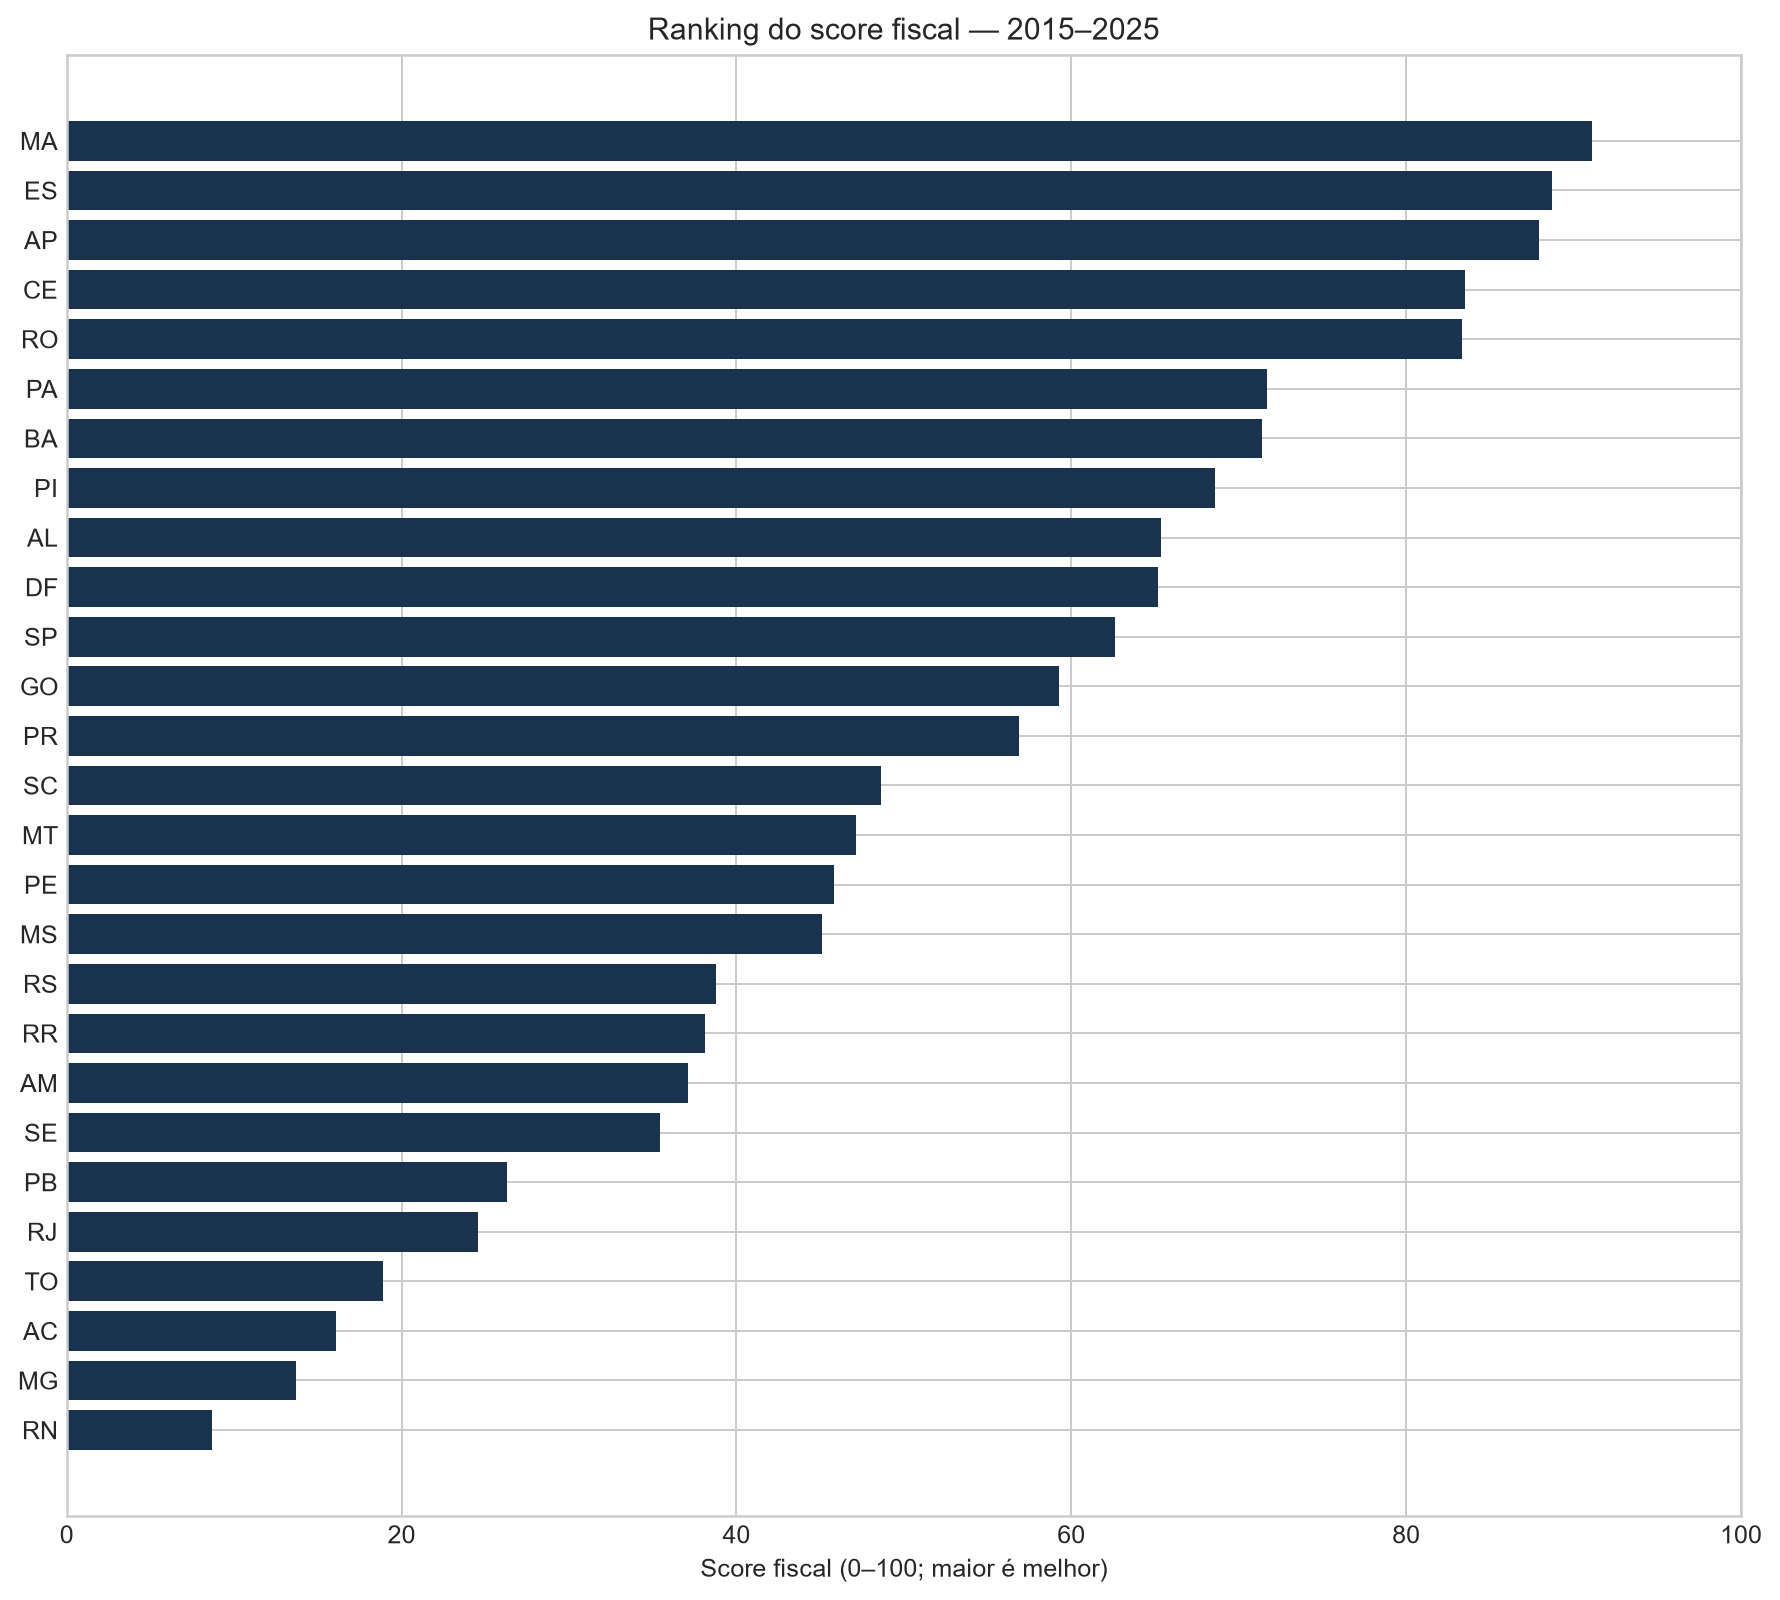

### Comparação entre períodos
Compara a média de 2015–2019 com 2020–2025.

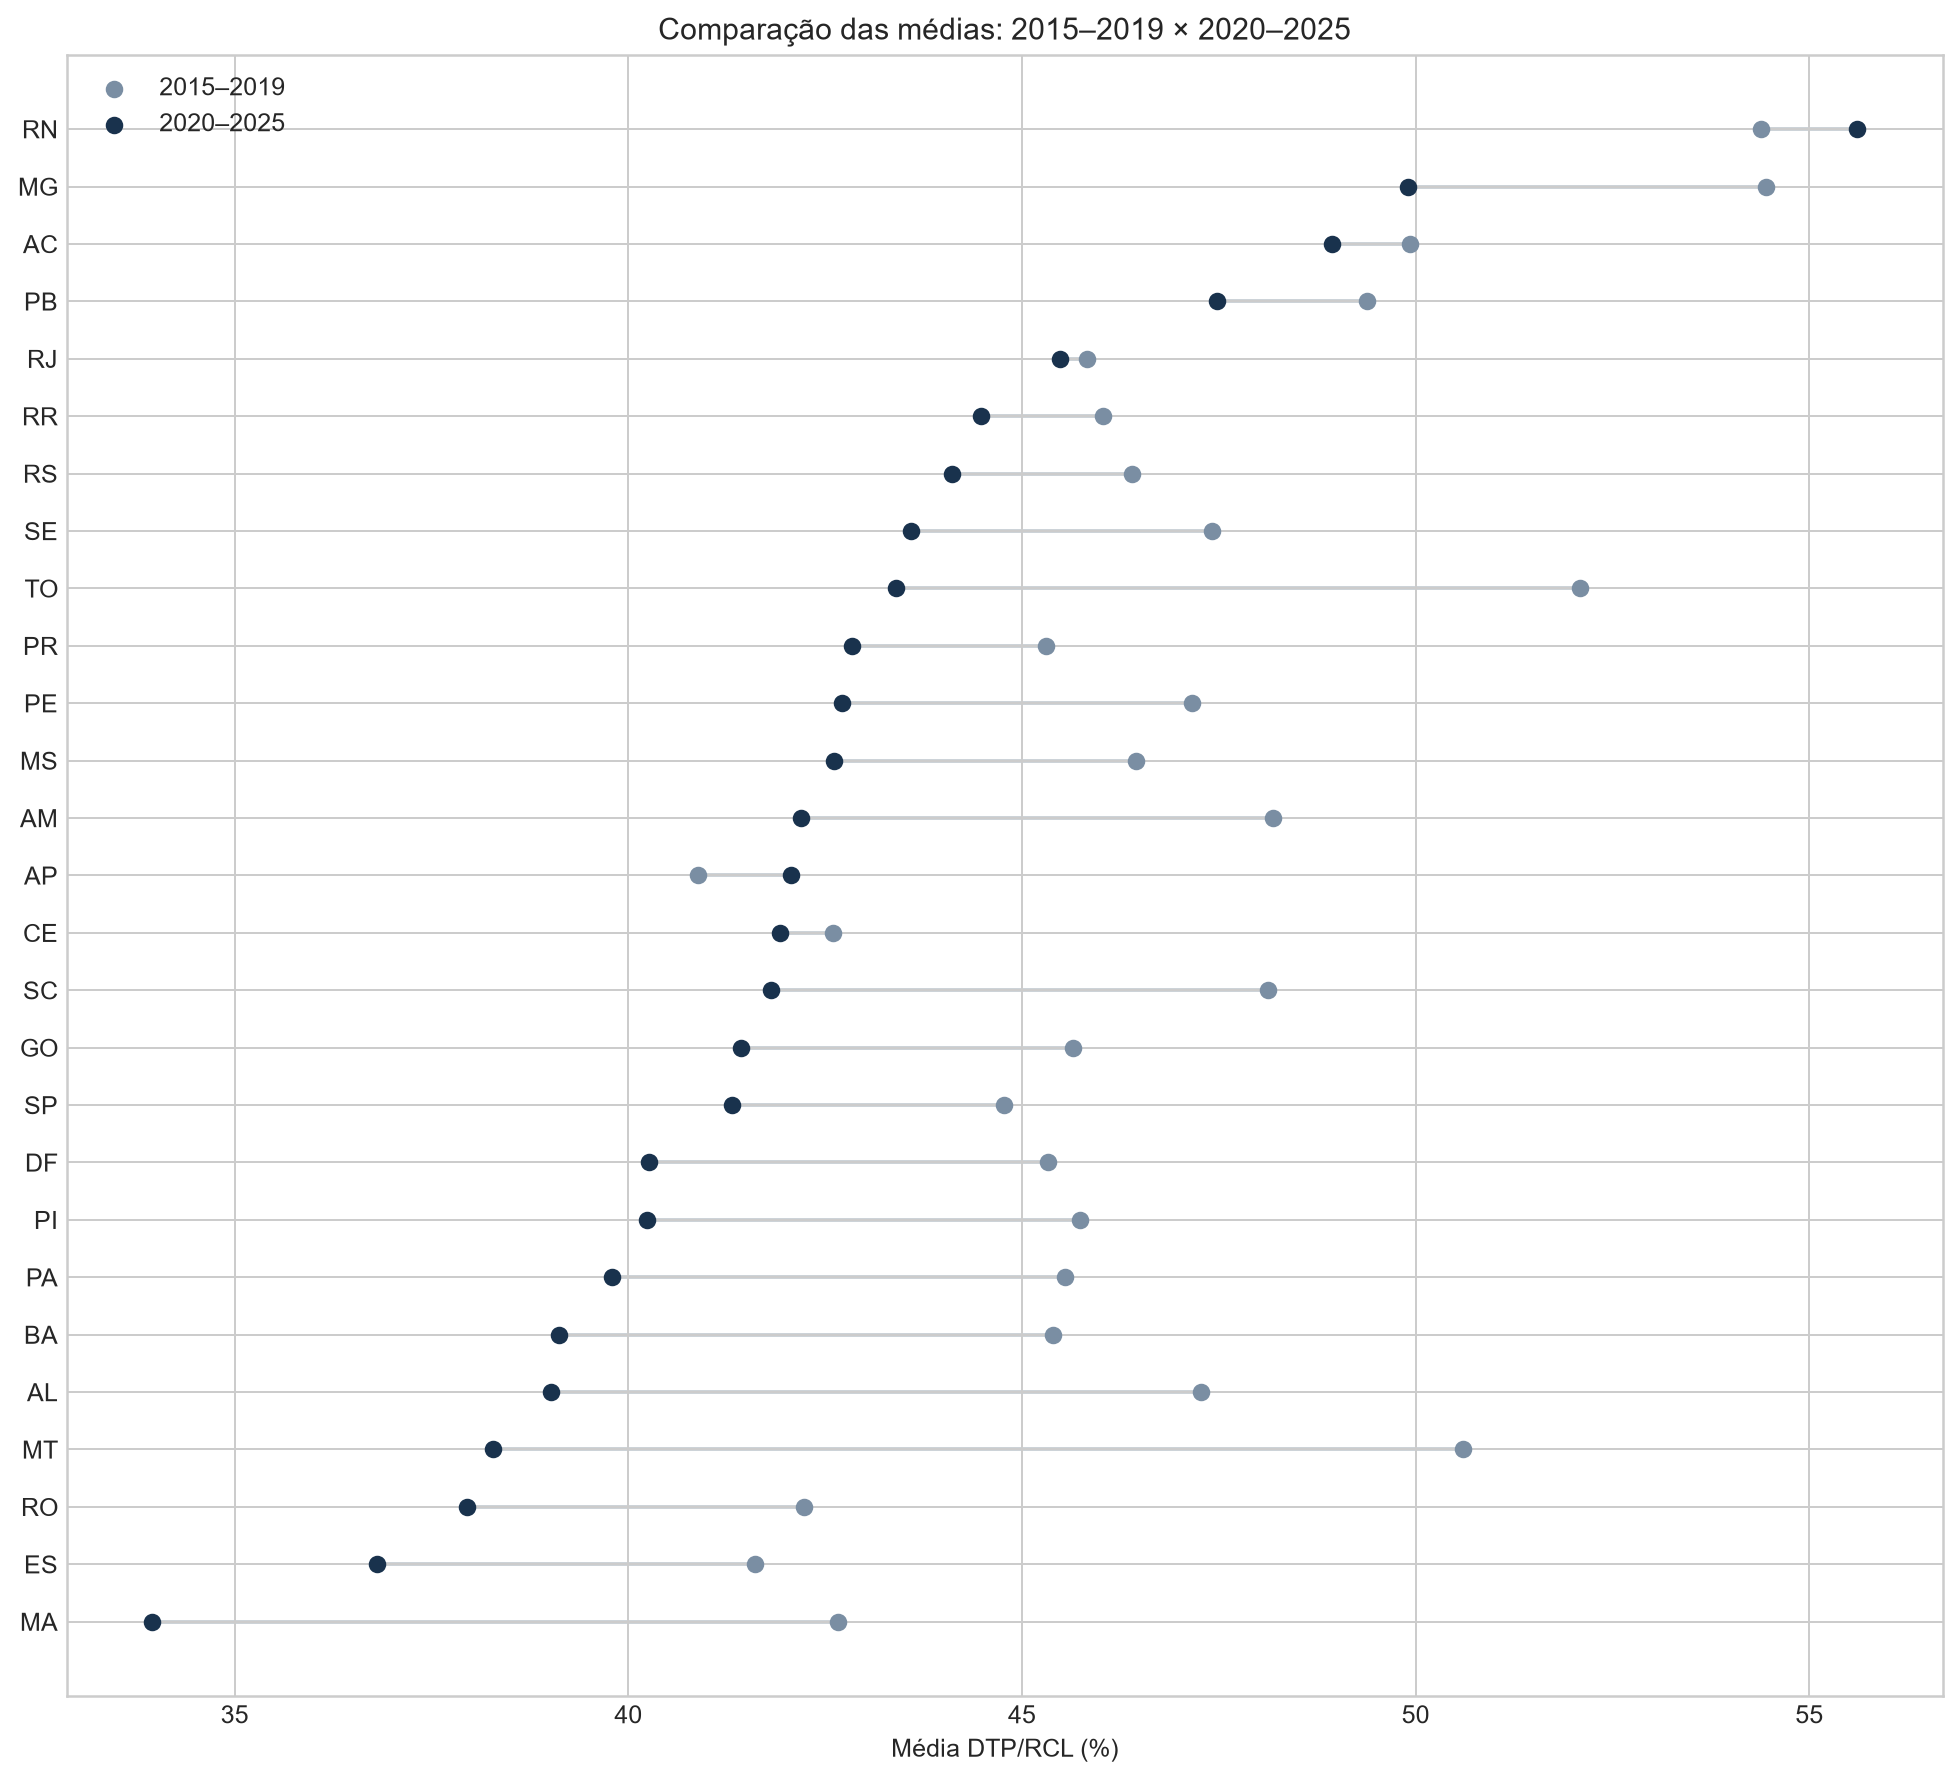

In [6]:
generate_charts(base, indicadores)
comentarios = {
 '01_ranking_ultimo_ano':('Ranking no último ano','Barras menores indicam menor comprometimento; as cores refletem a situação fiscal.'),
 '02_evolucao_todos_estados':('Evolução de todos os estados','Revela mudanças de patamar, convergência e divergência ao longo do tempo.'),
 '03_evolucao_5_melhores_5_piores':('Trajetória dos extremos','Contrasta os cinco melhores e os cinco piores scores.'),
 '04_heatmap_estado_ano':('Mapa de calor Estado × Ano','Tons quentes indicam maior comprometimento e ajudam a reconhecer persistência.'),
 '05_distancia_limite_prudencial':('Margem prudencial','Mostra o espaço em pontos percentuais; valores negativos exigem atenção.'),
 '06_distancia_limite_maximo':('Margem máxima','Evidencia a distância do patamar legal mais crítico.'),
 '07_ranking_score_fiscal':('Ranking do score','Agrega nível, margens, recorrência, tendência e volatilidade.'),
 '08_comparacao_periodos':('Comparação entre períodos','Compara a média de 2015–2019 com 2020–2025.')}
for arquivo in sorted((ROOT / 'graficos').glob('*.png')):
    titulo, texto = comentarios.get(arquivo.stem, (arquivo.stem,''))
    display(Markdown(f'### {titulo}\n{texto}'))
    display(Image(filename=str(arquivo), width=950))

## 6. Limitações

- O escopo é o Poder Executivo e não a soma dos poderes;
- mudanças do leiaute podem afetar comparações, sobretudo antes e depois de 2018;
- população é contextual e não integra o score;
- o score é relativo às 27 UFs e muda quando a série é atualizada;
- eventos extraordinários devem ser investigados nos demonstrativos de cada ente;
- a análise apoia o monitoramento, mas não substitui avaliação jurídica, contábil ou de controle externo.

## 7. Síntese para a alta gestão

A síntese automática reúne cenário atual, diferenças regionais, extremos do score, trajetórias, recorrência e riscos que merecem acompanhamento.

In [7]:
sintese = executive_summary(base, indicadores)
display(Markdown(sintese))
arquivo_excel = export_excel(base, indicadores, ranking)
display(Markdown(f'---\n**Excel atualizado:** `{arquivo_excel}`'))

# Panorama da Despesa com Pessoal dos Estados Brasileiros – RGF 2015–2025

## Síntese executiva

Escopo: Poder Executivo estadual, último quadrimestre disponível de cada exercício. No último ano disponível (2025), há 27 UFs com indicador válido. A leitura usa os limites declarados no próprio Anexo 01 do RGF.

Os cinco melhores resultados no score multidimensional são MA, ES, AP, CE, RO; os cinco piores são RN, MG, AC, TO, RJ. Em 2025, 9 UFs estavam em alerta ou acima de limite prudencial/máximo: RN (acima do limite máximo), MG (acima do limite prudencial), AC (acima do limite prudencial), RJ (alerta), RR (alerta), PB (alerta), TO (alerta), MS (alerta), RS (alerta). As médias regionais do DTP/RCL foram: Centro-Oeste: 40.48%; Nordeste: 41.30%; Norte: 41.46%; Sul: 41.78%; Sudeste: 42.66%.

Entre o primeiro e o último exercício, as maiores melhoras ocorreram em MT, MA, AM, SC, AL; as maiores deteriorações, em RJ, RN, MG, AC, MS. Na tendência dos três anos mais recentes, destacam-se melhora em MA, RR, AL, PA, SC e deterioração em DF, BA.

As maiores recorrências de ultrapassagem dos limites foram observadas em RN, MG, AC, PB, TO; as maiores volatilidades, em RJ, MT, MG, TO, RN. Os principais riscos para os próximos exercícios concentram-se nas UFs com margem pequena ou negativa, recorrência de ultrapassagens, tendência crescente e alta volatilidade. O score é comparativo e não substitui a avaliação legal de cada demonstrativo homologado.


---
**Excel atualizado:** `D:\Projetos\13 - APISiconfi_RGF\dados\rgf_estados_2015_2025.xlsx`